
# 12_pendulum_bipedalwalker_ppo_sb3.ipynb — Phase 1 (1C)
**Pendulum / BipedalWalker → PPO (Stable-Baselines3)**

Bu defter, Phase 1'in **1C** adımını uygular:
- Pendulum-v1 ve BipedalWalker-v3 için **PPO (SB3)** eğitimi
- Monitor wrapper, TensorBoard logları, checkpoint kayıtları
- Değerlendirme (evaluate_policy + EvalCallback)
- pygame render demo
- TensorBoard grafiklerini okuma ve karşılaştırma


## 1) Kurulum

In [1]:

# %pip install -U "stable-baselines3>=2.3.0" "gymnasium[box2d]>=0.29.1" tensorboard pandas matplotlib tqdm


## 2) Kütüphaneler

In [2]:

import os, time, uuid, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import gymnasium as gym
import stable_baselines3 as sb3
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.logger import configure
from stable_baselines3.common.utils import set_random_seed

print("Python", f"{os.sys.version.split()[0]}")
print("Gymnasium", gym.__version__)
print("SB3", sb3.__version__)
print("PyTorch", torch.__version__)
print("CUDA available", torch.cuda.is_available())
print("MPS available", torch.backends.mps.is_available())
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device", device)


Python 3.9.6
Gymnasium 1.1.1
SB3 2.6.0
PyTorch 2.7.1
CUDA available False
MPS available True
Using device mps


## 3) Konfigürasyon ve Klasörler

In [3]:

PHASE = "Phase 1"; STEP="1C"; NOTEBOOK="12_pendulum_bipedalwalker_ppo_sb3"
ENV_IDS = ["Pendulum-v1", "BipedalWalker-v3"]
SEED=42
TOTAL_STEPS={"Pendulum-v1":400_000,"BipedalWalker-v3":2_000_000}
EVAL_FREQ=25_000; SAVE_FREQ=100_000

PPO_CFG=dict(
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.0,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=dict(net_arch=dict(pi=[64,64], vf=[64,64]))
)

RUN_ID=time.strftime('%Y%m%d-%H%M%S')+f"-{uuid.uuid4().hex[:6]}"
ROOT_DIR=os.path.join("runs",PHASE,NOTEBOOK,RUN_ID)
CKPT_DIR=os.path.join(ROOT_DIR,"checkpoints")
MONITOR_DIR=os.path.join(ROOT_DIR,"monitor")
os.makedirs(CKPT_DIR,exist_ok=True); os.makedirs(MONITOR_DIR,exist_ok=True)
print("ROOT_DIR",ROOT_DIR)


ROOT_DIR runs/Phase 1/12_pendulum_bipedalwalker_ppo_sb3/20251001-142416-e67a0c


## 4) Ortam Hazırlama

In [4]:

def make_env(env_id, monitor_dir=None, render=False):
    if render: env=gym.make(env_id, render_mode="human")
    else: env=gym.make(env_id)
    if monitor_dir:
        md=os.path.join(monitor_dir, env_id)
        os.makedirs(md, exist_ok=True)
        env=Monitor(env, md)
    return env

test_env=make_env("Pendulum-v1", monitor_dir=MONITOR_DIR)
obs,_=test_env.reset(seed=SEED)
print("Obs shape",np.array(obs).shape,"Action space",test_env.action_space)
test_env.close()


Obs shape (3,) Action space Box(-2.0, 2.0, (1,), float32)


## 5) Eğitim Fonksiyonu

In [5]:

def train_ppo_on_env(env_id, total_steps, seed=SEED):
    env=make_env(env_id, monitor_dir=MONITOR_DIR)
    eval_env=make_env(env_id)
    env_log_dir=os.path.join(ROOT_DIR, env_id.replace("-","_"))
    os.makedirs(env_log_dir, exist_ok=True)
    tb_logger=configure(env_log_dir, ["stdout","csv","tensorboard"])
    model=PPO("MlpPolicy", env, **PPO_CFG, verbose=1, device="auto", seed=seed)
    model.set_logger(tb_logger)
    eval_cb=EvalCallback(eval_env,best_model_save_path=os.path.join(CKPT_DIR,env_id.replace("-","_")),
                         log_path=env_log_dir,eval_freq=EVAL_FREQ,n_eval_episodes=5,deterministic=True)
    ckpt_cb=CheckpointCallback(save_freq=SAVE_FREQ, save_path=os.path.join(CKPT_DIR,env_id.replace("-","_")))
    model.learn(total_timesteps=total_steps, callback=[eval_cb, ckpt_cb], progress_bar=True)
    model.save(os.path.join(CKPT_DIR, env_id.replace("-","_"), "final_ppo.zip"))
    mean_r,std_r=evaluate_policy(model, eval_env, n_eval_episodes=10)
    print(env_id,"Eval Mean",mean_r,"±",std_r)
    env.close(); eval_env.close()
    return env_log_dir


## 6) Eğitim Başlat

In [ ]:

TB_DIRS={}
for env_id in ENV_IDS:
    TB_DIRS[env_id]=train_ppo_on_env(env_id, TOTAL_STEPS[env_id])
print(TB_DIRS)


## 7) progress.csv Çiz

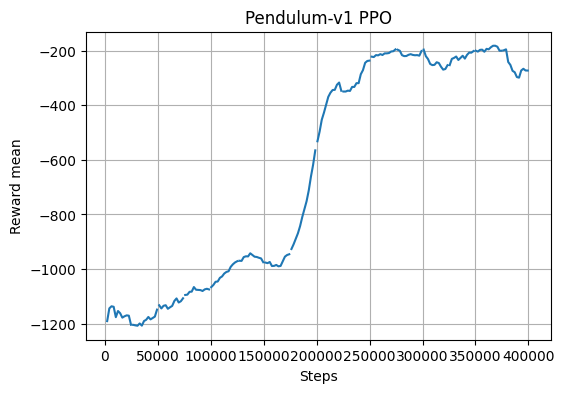

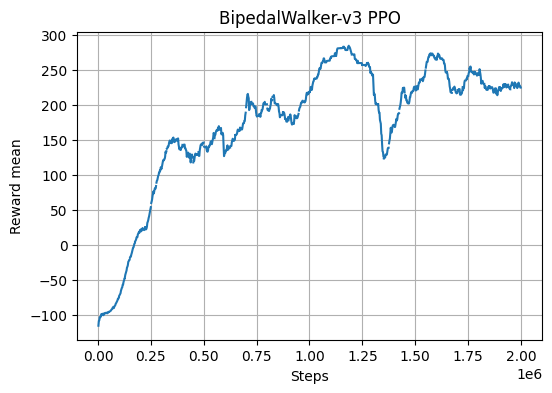

In [7]:

def plot_progress_csv(env_id, logdir):
    csv=os.path.join(logdir,"progress.csv")
    if not os.path.exists(csv):
        print(env_id,"no progress.csv")
        return
    df=pd.read_csv(csv)
    tcol=next((c for c in df.columns if "timesteps" in c), None)
    rcol=next((c for c in df.columns if "rew_mean" in c), None)
    if not (tcol and rcol): return
    plt.figure(figsize=(6,4))
    plt.plot(df[tcol], df[rcol])
    plt.title(env_id+" PPO")
    plt.xlabel("Steps"); plt.ylabel("Reward mean")
    plt.grid(True); plt.show()

for env,dir in TB_DIRS.items():
    plot_progress_csv(env, dir)


## 8) TensorBoard Eval Reward

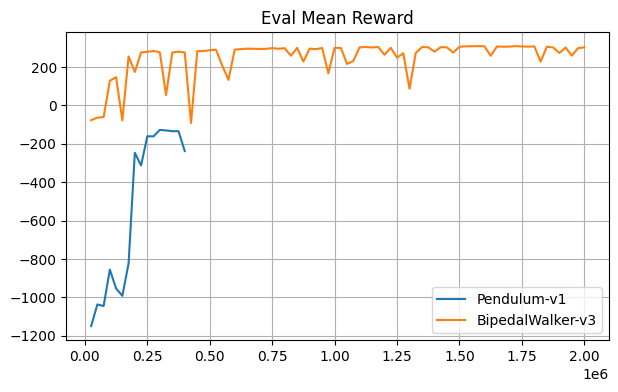

In [8]:

from tensorboard.backend.event_processing import event_accumulator as ea
def load_tb_scalar(run_dir, tag):
    files=[os.path.join(root,f) for root,_,fs in os.walk(run_dir) for f in fs if f.startswith("events")]
    if not files: return pd.DataFrame(columns=["step","val"])
    dfs=[]
    for f in files:
        acc=ea.EventAccumulator(f); acc.Reload()
        if tag in acc.Tags().get("scalars",[]):
            scal=acc.Scalars(tag)
            steps=[s.step for s in scal]; vals=[s.value for s in scal]
            dfs.append(pd.DataFrame({"step":steps,"val":vals}))
    if not dfs: return pd.DataFrame(columns=["step","val"])
    out=pd.concat(dfs).groupby("step",as_index=False)["val"].mean()
    return out

plt.figure(figsize=(7,4))
for env,dir in TB_DIRS.items():
    df=load_tb_scalar(dir,"eval/mean_reward")
    if len(df): plt.plot(df["step"], df["val"], label=env)
plt.legend(); plt.title("Eval Mean Reward"); plt.grid(True); plt.show()


## 9) Render Demo

In [ ]:

def render_demo(env_id, ckpt_subdir, model_name="final_ppo.zip", episodes=3):
    env=make_env(env_id, render=True)
    path=os.path.join(CKPT_DIR, ckpt_subdir, model_name)
    if not os.path.exists(path):
        print("Model yok:", path); return
    model=PPO.load(path, env=env)
    for ep in range(episodes):
        obs,_=env.reset(seed=SEED+ep)
        done=truncated=False; ret=0
        while not (done or truncated):
            action,_=model.predict(obs, deterministic=True)
            obs,r,done,truncated,_=env.step(action); ret+=r
        print(env_id,"Ep",ep,"Return",ret)
    env.close()

# Örnek kullanım: her eğitimli ortam için checkpoint alt klasörünü kullanarak render
for env in ENV_IDS:
    ckpt_subdir = env.replace("-", "_")  # training saved checkpoints under CKPT_DIR/<env_with_underscores>
    render_demo(env, ckpt_subdir, model_name="final_ppo.zip", episodes=3)


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Pendulum-v1 Ep 0 Return -129.53049161701477
Pendulum-v1 Ep 1 Return -133.13451702117845
Pendulum-v1 Ep 2 Return -246.7868451612088
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
BipedalWalker-v3 Ep 0 Return 303.33777
BipedalWalker-v3 Ep 1 Return 300.83075
BipedalWalker-v3 Ep 2 Return 300.00067


: 

## 10) PPO Teori


- PPO clipping objective
- Generalized Advantage Estimation
- Important TB metrikleri: rollout/ep_rew_mean, policy_loss, value_loss, entropy, approx_kl, clip_fraction
- Pendulum: ödül 0'a yaklaşmalı (negatiften yukarı)
- BipedalWalker: 300+ skor çözülmüş kabul edilir
